# Recommendation quality in three IMF technical-assistance reports

This notebook validates and summarizes a schema-constrained reference assessment of 24 recommendations (eight per report). Scores are model judgments produced by the Part C prompt; they are not human ratings, and the purposive sample does not support population-wide claims about IMF recommendations.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RESULTS = ROOT / "data" / "results"

assessments = pd.read_csv(RESULTS / "recommendation_quality_assessments.csv")
summary = pd.read_csv(RESULTS / "recommendation_quality_summary.csv")
assessments.shape, summary.shape

((24, 26), (3, 14))

## Validation checks

In [2]:
score_columns = [
    "specificity_score",
    "actionability_score",
    "internal_consistency_score",
    "overall_score",
]

assert len(assessments) == 24
assert assessments["recommendation_id"].is_unique
assert assessments.groupby("country").size().eq(8).all()
assert assessments[score_columns].notna().all().all()
assert assessments[score_columns].apply(lambda col: col.between(1, 5).all()).all()
assert assessments["original_text"].str.strip().ne("").all()
print("Passed: 24 unique, complete, in-range assessments with an 8/8/8 report split.")

Passed: 24 unique, complete, in-range assessments with an 8/8/8 report split.


## Report-level comparison

In [3]:
display_columns = [
    "country",
    "n_recommendations",
    "mean_specificity",
    "mean_actionability",
    "mean_internal_consistency",
    "mean_overall",
    "high_count",
    "medium_count",
    "low_count",
]
summary[display_columns].style.format(
    {
        "mean_specificity": "{:.2f}",
        "mean_actionability": "{:.2f}",
        "mean_internal_consistency": "{:.2f}",
        "mean_overall": "{:.2f}",
    }
)

,country,n_recommendations,mean_specificity,mean_actionability,mean_internal_consistency,mean_overall,high_count,medium_count,low_count
0,Azerbaijan,8,2.88,2.75,5.00,3.56,0,8,0
1,Ukraine,8,3.00,3.00,4.88,3.64,1,7,0
2,Sri Lanka,8,2.88,2.75,4.88,3.51,1,7,0


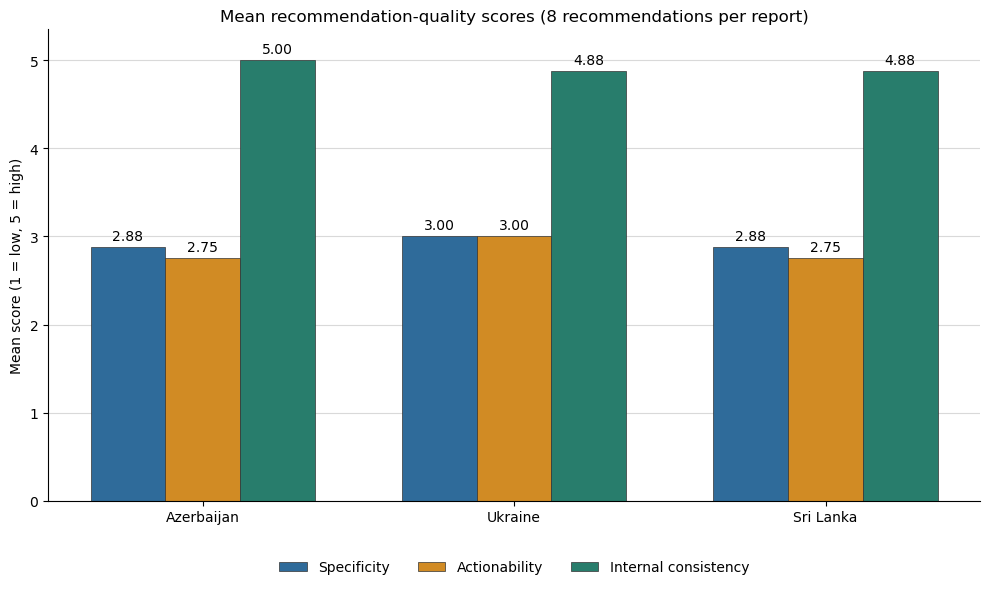

In [4]:
dimensions = [
    ("Specificity", "mean_specificity", "#2F6B9A"),
    ("Actionability", "mean_actionability", "#D18B24"),
    ("Internal consistency", "mean_internal_consistency", "#287D6C"),
]
x = np.arange(len(summary))
width = 0.24

fig, ax = plt.subplots(figsize=(10, 6), facecolor="white")
for index, (label, field, color) in enumerate(dimensions):
    values = summary[field].tolist()
    bars = ax.bar(
        x + (index - 1) * width,
        values,
        width,
        label=label,
        color=color,
        edgecolor="#333333",
        linewidth=0.5,
    )
    ax.bar_label(bars, labels=[f"{value:.2f}" for value in values], padding=3)

ax.set_title("Mean recommendation-quality scores (8 recommendations per report)")
ax.set_ylabel("Mean score (1 = low, 5 = high)")
ax.set_xticks(x, summary["country"])
ax.set_ylim(0, 5.35)
ax.set_yticks(range(6))
ax.grid(axis="y", color="#D9D9D9", linewidth=0.8)
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.10), ncol=3, frameon=False)
fig.tight_layout()
plt.show()

## Distribution and diagnostic cases

In [5]:
overall = {
    "n": len(assessments),
    "mean_specificity": assessments["specificity_score"].mean(),
    "mean_actionability": assessments["actionability_score"].mean(),
    "mean_internal_consistency": assessments["internal_consistency_score"].mean(),
    "mean_overall": assessments["overall_score"].mean(),
}
pd.Series(overall).round(2)

n                            24.00
mean_specificity              2.92
mean_actionability            2.83
mean_internal_consistency     4.92
mean_overall                  3.57
dtype: float64

In [6]:
assessment_mix = pd.crosstab(
    assessments["country"],
    assessments["overall_assessment"],
).reindex(columns=["High", "Medium", "Low"], fill_value=0)
evidence_mix = pd.crosstab(
    assessments["country"],
    assessments["evidence_status"],
)
assessment_mix, evidence_mix

(overall_assessment  High  Medium  Low
 country                              
 Azerbaijan             0       8    0
 Sri Lanka              1       7    0
 Ukraine                1       7    0,
 evidence_status  partially_supported  supported
 country                                        
 Azerbaijan                         0          8
 Sri Lanka                          1          7
 Ukraine                            1          7)

In [7]:
diagnostic = assessments.loc[
    (assessments["specificity_score"] <= 2) | (assessments["actionability_score"] <= 2),
    [
        "country",
        "recommendation_id",
        "original_text",
        "specificity_score",
        "actionability_score",
        "internal_consistency_score",
        "overall_score",
    ],
].sort_values(["overall_score", "recommendation_id"])
diagnostic

,country,recommendation_id,original_text,specificity_score,actionability_score,internal_consistency_score,overall_score
7,Azerbaijan,AZE-008,Streamline the monetary policy communication c...,2,2,5,3.0
19,Sri Lanka,LKA-004,Operationalize the ELA framework .,2,2,5,3.0
21,Sri Lanka,LKA-006,Introduce fine tuning operations if (please ad...,2,2,5,3.0
3,Azerbaijan,AZE-004,"Ensure well-rounded short-, medium- and long-t...",3,2,5,3.3
9,Ukraine,UKR-002,Introduce a new counterparty measure of limita...,2,3,5,3.3


## Interpretation

- The strongest pattern is alignment rather than standalone operational detail: internal-consistency means are 4.88–5.00, while specificity and actionability means are 2.75–3.00.
- Ukraine has the highest mean overall score in this sample, but the between-report differences are small and should not be interpreted as a ranking of countries or IMF teams.
- The arithmetic mean can hide a weak dimension. For example, a recommendation with an editorial placeholder can remain “Medium” overall when the body strongly supports its intended direction; dimension-level scores and justifications should therefore remain visible.
- Nearly every recommendation is supported by its report body. The practical improvement opportunity is to make the recommendation rows more self-contained by naming ownership, sequencing, operating conditions, and completion criteria where relevant.

## Limitations

The sample is purposive, limited to eight recommendations from each of three reports, and includes a deliberately retained low-specificity edge case from the Sri Lanka source table. Scores come from one schema-constrained model run and were automatically checked for structure, source identity, verbatim recommendation text, and evidence substrings, but they were not independently adjudicated by a monetary-policy expert.